In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
import mne

print("MNE version:", mne.__version__)
print("Everything is working!")

MNE version: 1.12.1
Everything is working!


In [2]:

import scipy.io as sio

data = sio.loadmat(
    "../data/gNautilus_CheckerboardVEP.mat",
    squeeze_me=True
)

print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'ch_names', 'class_names', 'class_vec', 'event_marker', 'fs', 'group_id', 'sample_marker', 'y', 'y_filtered'])


In [3]:

ch_names = data["ch_names"]
fs = int(data["fs"])
eeg_data = data["y"]
filtered_data = data["y_filtered"]
events = data["event_marker"]

print("Sampling frequency:", fs)
print("Number of channels:", len(ch_names))
print("EEG data shape:", eeg_data.shape)
print("Filtered data shape:", filtered_data.shape)
print("Number of events:", len(events))
print("Channels:", ch_names)

Sampling frequency: 500
Number of channels: 16
EEG data shape: (25001, 16)
Filtered data shape: (25001, 16)
Number of events: 50
Channels: ['FP1' 'FP2' 'F3' 'Fz' 'F4' 'T7' 'C3' 'Cz' 'C4' 'T8' 'P3' 'Pz' 'P4' 'PO7'
 'PO8' 'Oz']


In [4]:

# Make sure EEG data is in the format MNE expects:
# channels × samples

eeg_for_mne = eeg_data.T

info = mne.create_info(
    ch_names=list(ch_names),
    sfreq=fs,
    ch_types="eeg"
)

raw = mne.io.RawArray(
    eeg_for_mne,
    info
)

print(raw)

Creating RawArray with float64 data, n_channels=16, n_times=25001
    Range : 0 ... 25000 =      0.000 ...    50.000 secs
Ready.
<RawArray | 16 x 25001 (50.0 s), ~3.1 MiB, data loaded>


In [5]:

print(raw.info["ch_names"])
print("Sampling frequency:", raw.info["sfreq"])
print("Number of channels:", raw.info["nchan"])

['FP1', 'FP2', 'F3', 'Fz', 'F4', 'T7', 'C3', 'Cz', 'C4', 'T8', 'P3', 'Pz', 'P4', 'PO7', 'PO8', 'Oz']
Sampling frequency: 500.0
Number of channels: 16


Using matplotlib as 2D backend.


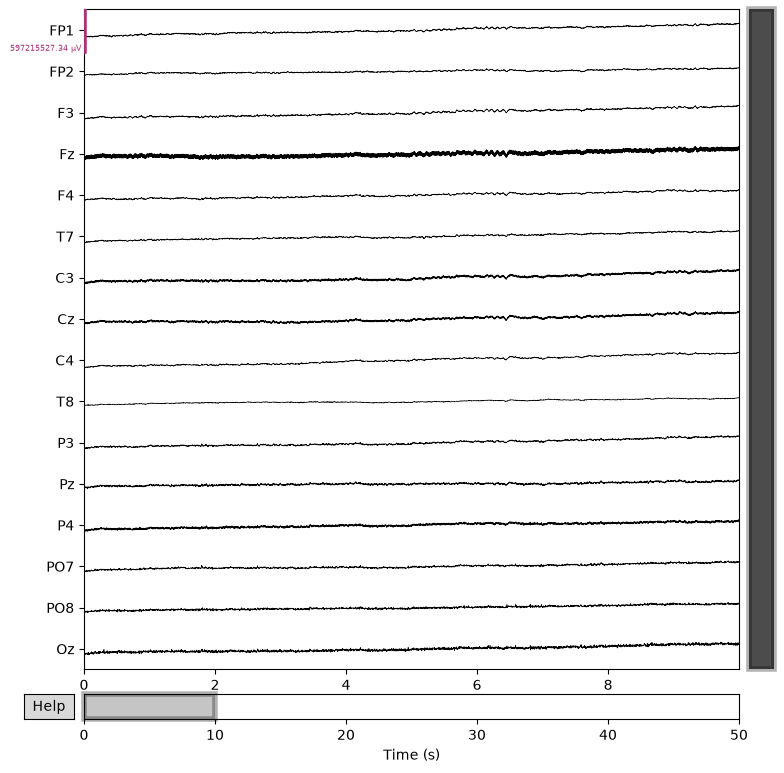

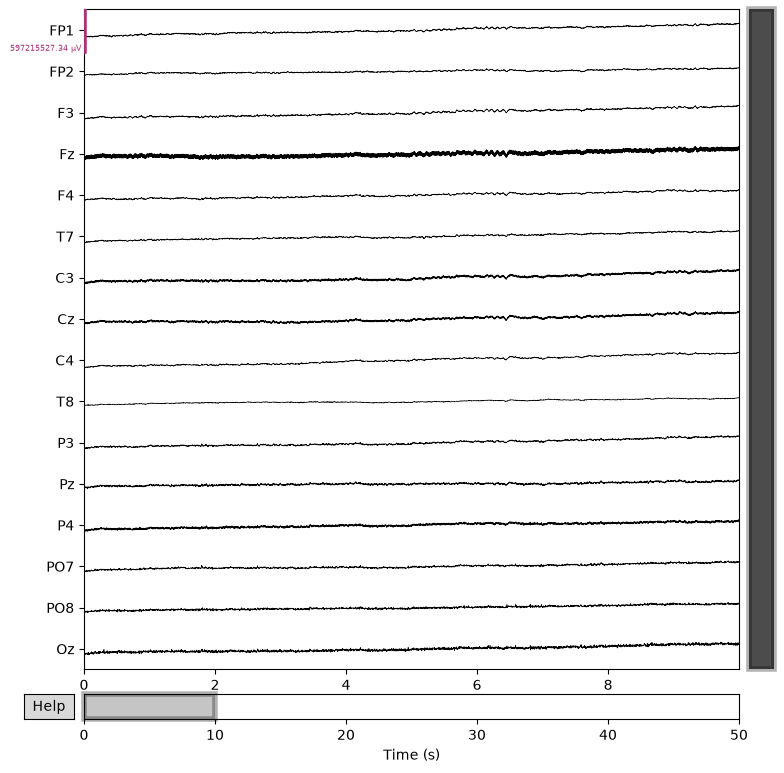

In [6]:
raw.plot(
    duration=10,
    n_channels=16,
    scalings="auto"
)

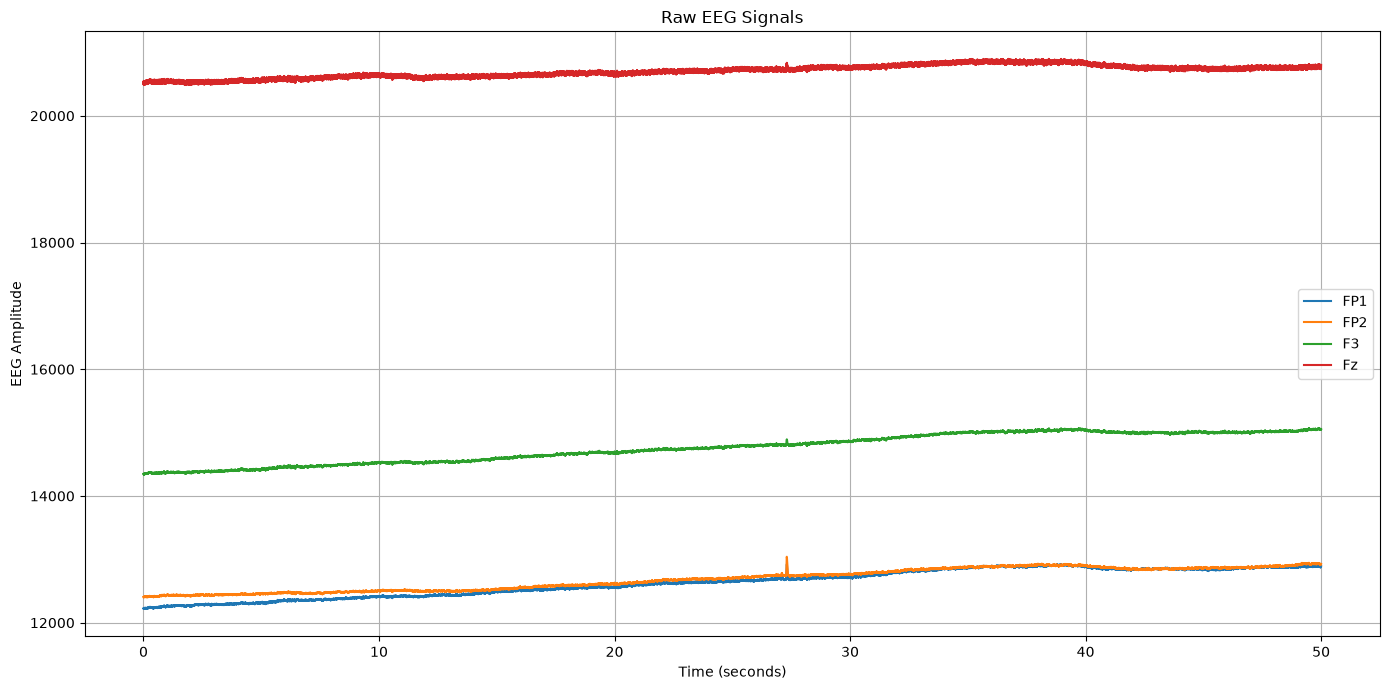

In [7]:
# Time axis
times = np.arange(eeg_data.shape[0]) / fs

# Plot 4 EEG channels
plt.figure(figsize=(14, 7))

for i in range(4):
    plt.plot(
        times,
        eeg_data[:, i],
        label=ch_names[i]
    )

plt.xlabel("Time (seconds)")
plt.ylabel("EEG Amplitude")
plt.title("Raw EEG Signals")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
print(ch_names)

['FP1' 'FP2' 'F3' 'Fz' 'F4' 'T7' 'C3' 'Cz' 'C4' 'T8' 'P3' 'Pz' 'P4' 'PO7'
 'PO8' 'Oz']


In [9]:
# Find the important visual channels
visual_channels = ["PO7", "PO8", "Oz"]

visual_indices = [
    list(ch_names).index(ch)
    for ch in visual_channels
]

print("Visual channel indices:", visual_indices)

Visual channel indices: [13, 14, 15]


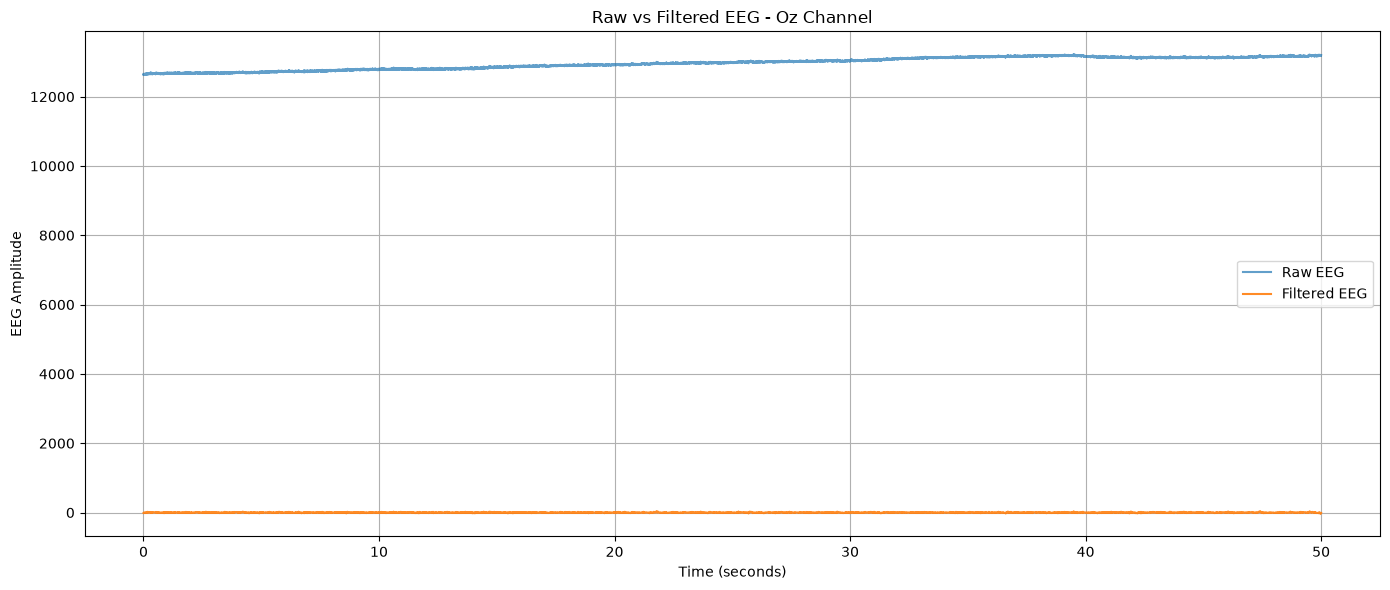

In [10]:
# Compare raw and filtered EEG at Oz

oz_index = list(ch_names).index("Oz")

plt.figure(figsize=(14, 6))

plt.plot(
    times,
    eeg_data[:, oz_index],
    label="Raw EEG",
    alpha=0.7
)

plt.plot(
    times,
    filtered_data[:, oz_index],
    label="Filtered EEG",
    alpha=0.9
)

plt.xlabel("Time (seconds)")
plt.ylabel("EEG Amplitude")
plt.title("Raw vs Filtered EEG - Oz Channel")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
print("Number of events:", len(events))
print("First 10 event markers:")
print(events[:10])


Number of events: 50
First 10 event markers:
[3170 3330 3746 4282 4570 5234 5898 6058 6346 6882]


In [12]:
mne_events = np.column_stack([
    events.astype(int),
    np.zeros(len(events), dtype=int),
    np.ones(len(events), dtype=int)
])

mne_events = mne_events.astype(int)

print("MNE events shape:", mne_events.shape)
print(mne_events[:10])

MNE events shape: (50, 3)
[[3170    0    1]
 [3330    0    1]
 [3746    0    1]
 [4282    0    1]
 [4570    0    1]
 [5234    0    1]
 [5898    0    1]
 [6058    0    1]
 [6346    0    1]
 [6882    0    1]]


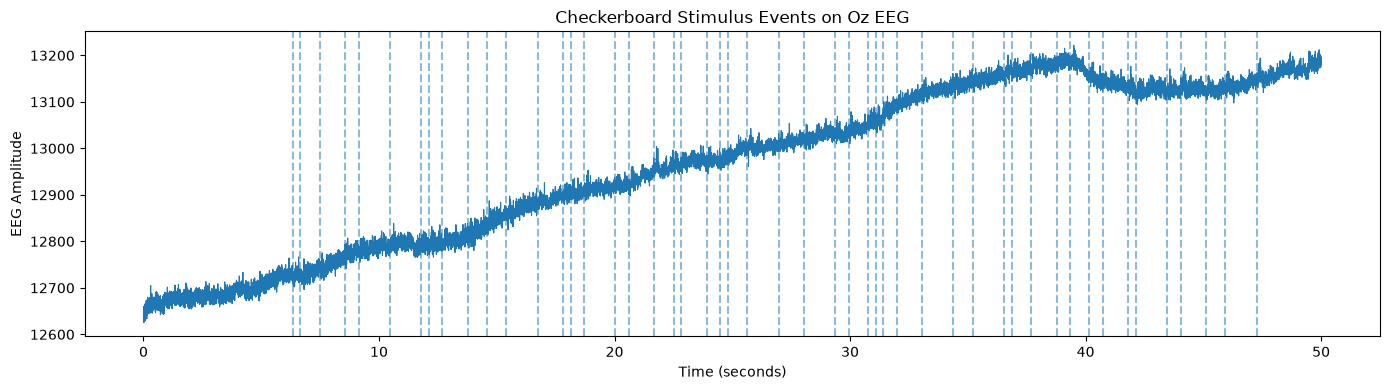

In [13]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(
    times,
    eeg_data[:, oz_index],
    linewidth=0.8
)

for event in events:
    event_time = event / fs
    ax.axvline(
        event_time,
        linestyle="--",
        alpha=0.5
    )

ax.set_xlabel("Time (seconds)")
ax.set_ylabel("EEG Amplitude")
ax.set_title("Checkerboard Stimulus Events on Oz EEG")

plt.tight_layout()
plt.show()